<style>
.jp-Notebook, .jp-NotebookPanel-notebook, main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}
.jp-RenderedHTMLCommon p, .text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}
.jp-OutputArea-output img, .jp-RenderedImage img, .output_png img,
div.output_area img, div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}
.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}
.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}
.interpretation-label { font-style: italic; font-weight: 600; }
</style>

# Jump Integration and Poisson Random Measures

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def poisson_events(rate, horizon, rng):
    count = rng.poisson(rate * horizon)
    return np.sort(rng.uniform(0.0, horizon, count))

## 1. Counting processes have two values at a jump

Let $(N_t)_{t\geq 0}$ be a Poisson process of rate $\lambda$. Its jump times are $T_1<T_2<\cdots$, and

$$
N_t=\sum_{i\geq 1}\mathbf 1_{\{T_i\leq t\}}.
$$

At $T_i$, the right-continuous value is $N_{T_i}=i$, whereas the left limit is $N_{T_i-}=i-1$. This distinction is structural: a predictable integrand may depend on information available immediately before the jump, so state-dependent jump coefficients are evaluated at $X_{t-}$.

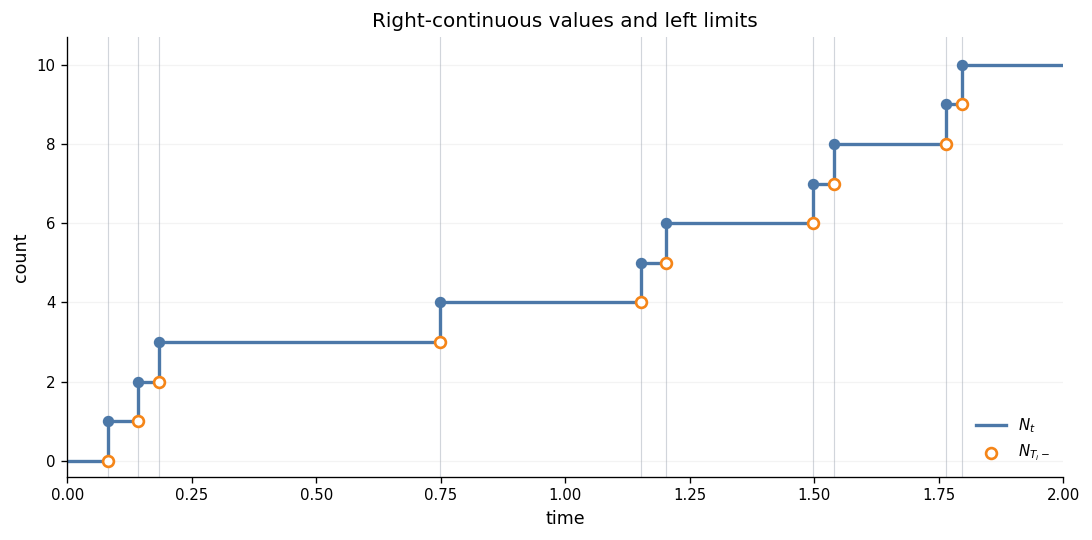

In [2]:
rng = np.random.default_rng(SEED + 1)
rate = 4.5
horizon = 2.0
events = poisson_events(rate, horizon, rng)

grid = np.r_[0.0, events, horizon]
counts = np.arange(grid.size)
counts[-1] = len(events)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.step(grid, counts, where="post", color=BLUE, linewidth=2.0, label=r"$N_t$")
ax.scatter(events, np.arange(1, len(events) + 1), color=BLUE, s=34, zorder=3)
ax.scatter(
    events,
    np.arange(len(events)),
    facecolors="white",
    edgecolors=ORANGE,
    linewidths=1.6,
    s=42,
    zorder=4,
    label=r"$N_{T_i-}$",
)
for time in events:
    ax.axvline(time, color=LIGHT_GREY, linewidth=0.7, zorder=0)
ax.set(xlabel="time", ylabel="count", title="Right-continuous values and left limits")
ax.set_xlim(0.0, horizon)
ax.set_ylim(-0.4, len(events) + 0.7)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> A Poisson counting path, with filled points for $N_{T_i}$ and open points for the pre-jump values $N_{T_i-}$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> At every jump time the two values differ by one. The left limit contains only pre-jump information and is therefore the relevant state when a jump coefficient must be predictable.</p>

## 2. A marked point process is a random measure

Attach a mark $Z_i$ in a measurable mark space $E$ to each jump time $T_i$. The associated Poisson random measure is

$$
N((0,t]\times A)=\sum_{i\geq 1}\mathbf 1_{\{T_i\leq t,\,Z_i\in A\}},
$$

with intensity measure $\nu(dz)\,dt$. For a predictable integrand $H$ for which the integral is defined,

$$
\int_0^t\!\int_E H(s,z)\,N(ds,dz)
=\sum_{T_i\leq t}H(T_i,Z_i).
$$

Thus the random-measure notation is a compact form of a sum over random jump times and marks.

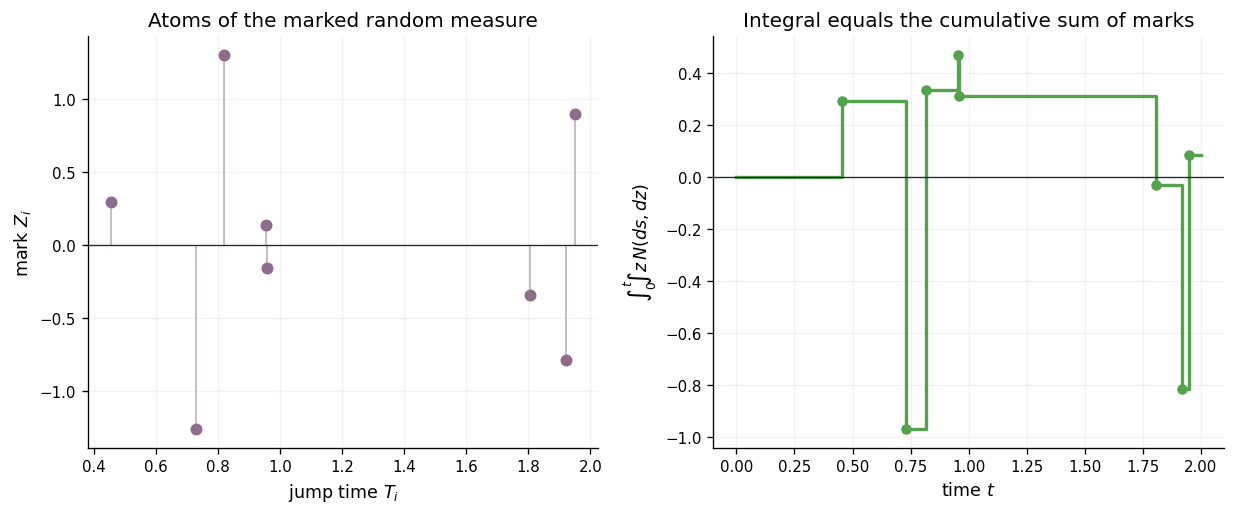

In [3]:
rng = np.random.default_rng(SEED + 2)
rate = 5.0
horizon = 2.0
events = poisson_events(rate, horizon, rng)
marks = rng.normal(loc=0.35, scale=0.75, size=len(events))
cumulative_integral = np.cumsum(marks)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
axes[0].scatter(events, marks, color=PURPLE, s=38)
axes[0].vlines(events, 0.0, marks, color=PURPLE, alpha=0.45, linewidth=1.2)
axes[0].axhline(0.0, color=INK, linewidth=0.8)
axes[0].set(xlabel="jump time $T_i$", ylabel="mark $Z_i$", title="Atoms of the marked random measure")

sum_grid = np.r_[0.0, events, horizon]
sum_values = np.r_[0.0, cumulative_integral, cumulative_integral[-1] if len(events) else 0.0]
axes[1].step(sum_grid, sum_values, where="post", color=GREEN, linewidth=2.0)
axes[1].scatter(events, cumulative_integral, color=GREEN, s=28, zorder=3)
axes[1].axhline(0.0, color=INK, linewidth=0.8)
axes[1].set(
    xlabel="time $t$",
    ylabel=r"$\int_0^t\!\int z\,N(ds,dz)$",
    title="Integral equals the cumulative sum of marks",
)
for ax in axes:
    ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> The atoms $(T_i,Z_i)$ of a marked Poisson random measure and the integral obtained with the deterministic integrand $H(s,z)=z$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Each atom contributes exactly its mark to the integral. The integral changes only when the random measure records an atom, which is why jump integrals are naturally represented as random sums.</p>

## 3. Predictability means pre-jump evaluation

Consider $H(s,z)=N_{s-}\phi(z)$, where $\phi$ is measurable. Because $N_{s-}$ is predictable,

$$
\int_0^t\!\int_E N_{s-}\phi(z)\,N(ds,dz)
=\sum_{T_i\leq t}(i-1)\phi(Z_i).
$$

Replacing $N_{s-}$ by $N_s$ would use the current jump when determining its own coefficient. The resulting post-jump sum can be computed pathwise, but $N_s\phi(z)$ is not a predictable integrand and therefore is not the admissible stochastic integral in this construction.

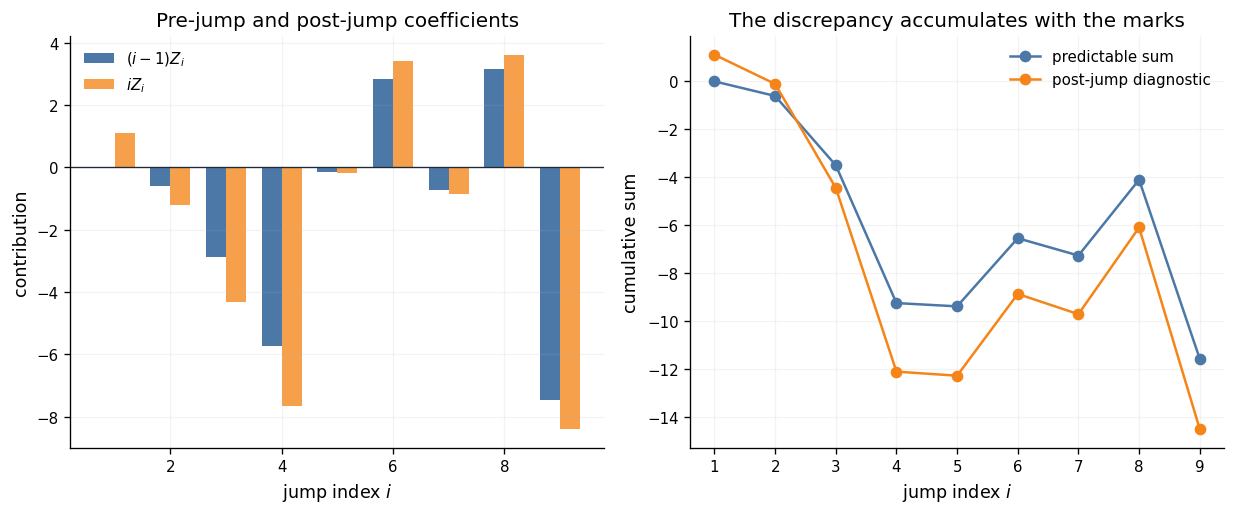

In [4]:
rng = np.random.default_rng(SEED + 3)
event_count = 9
marks = rng.normal(size=event_count)
indices = np.arange(1, event_count + 1)
predictable_terms = (indices - 1) * marks
post_jump_terms = indices * marks

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
width = 0.36
axes[0].bar(indices - width / 2, predictable_terms, width, color=BLUE, label=r"$(i-1)Z_i$")
axes[0].bar(indices + width / 2, post_jump_terms, width, color=ORANGE, alpha=0.78, label=r"$iZ_i$")
axes[0].axhline(0.0, color=INK, linewidth=0.8)
axes[0].set(xlabel="jump index $i$", ylabel="contribution", title="Pre-jump and post-jump coefficients")
axes[0].legend(frameon=False)

axes[1].plot(indices, np.cumsum(predictable_terms), marker="o", color=BLUE, label="predictable sum")
axes[1].plot(indices, np.cumsum(post_jump_terms), marker="o", color=ORANGE, label="post-jump diagnostic")
axes[1].set(xlabel="jump index $i$", ylabel="cumulative sum", title="The discrepancy accumulates with the marks")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Contributions from the predictable coefficient $N_{T_i-}=i-1$ and from the post-jump diagnostic $N_{T_i}=i$ when $\phi(z)=z$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The contribution at jump $i$ differs by $Z_i$. This is not a discretization convention: using $N_{T_i}$ lets the current atom enter its own coefficient, whereas the predictable integral uses only information available before that atom arrives.</p>

## 4. Compensation extracts the martingale part

If $N$ has intensity $\nu(dz)\,dt$, its compensated version is

$$
\widetilde N(ds,dz)=N(ds,dz)-\nu(dz)\,ds.
$$

For a predictable $H$ satisfying $E\int_0^T\int_E H(s,z)^2\nu(dz)ds<\infty$, the compensated integral

$$
M_t=\int_0^t\!\int_E H(s,z)\,\widetilde N(ds,dz)
$$

is a square-integrable martingale, and the isometry gives

$$
E[M_t^2]=E\int_0^t\!\int_E H(s,z)^2\nu(dz)ds.
$$

For exponential marks with mean one and $H(s,z)=z$, this becomes $M_t=\sum_{T_i\leq t}Z_i-\lambda t$ and $E[M_t^2]=2\lambda t$.

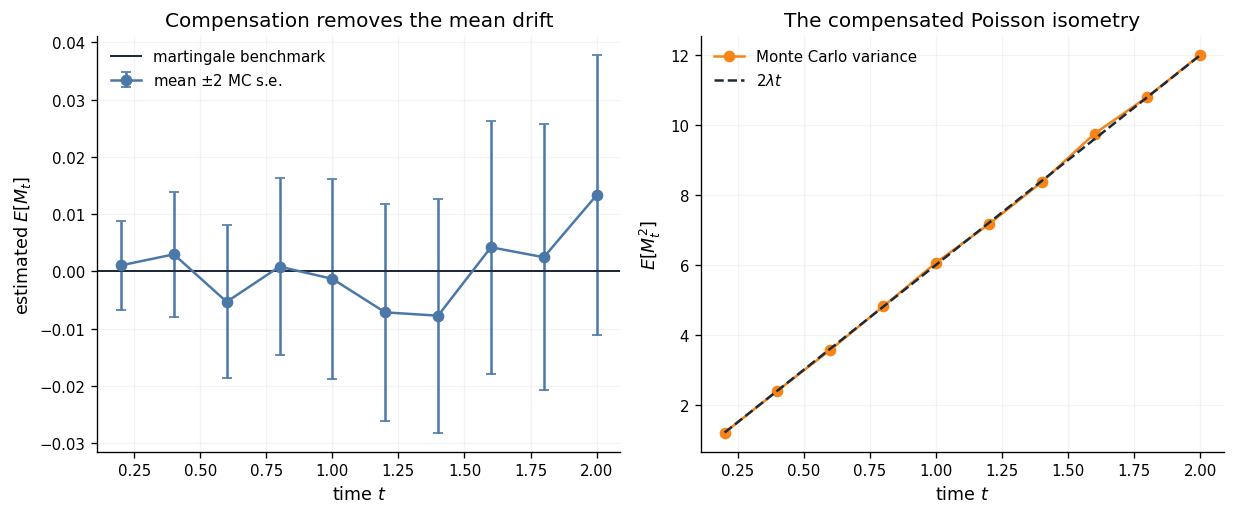

In [5]:
rng = np.random.default_rng(SEED + 4)
rate = 3.0
times = np.linspace(0.2, 2.0, 10)
paths = 80_000
means = []
standard_errors = []
variances = []

for time in times:
    counts = rng.poisson(rate * time, size=paths)
    compound_sum = rng.gamma(shape=counts, scale=1.0)
    compensated = compound_sum - rate * time
    means.append(compensated.mean())
    standard_errors.append(compensated.std(ddof=1) / np.sqrt(paths))
    variances.append(compensated.var(ddof=1))

means = np.asarray(means)
standard_errors = np.asarray(standard_errors)
variances = np.asarray(variances)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
axes[0].errorbar(times, means, yerr=2 * standard_errors, color=BLUE, marker="o", capsize=3, label=r"mean $\pm 2$ MC s.e.")
axes[0].axhline(0.0, color=INK, linewidth=1.2, label="martingale benchmark")
axes[0].set(xlabel="time $t$", ylabel=r"estimated $E[M_t]$", title="Compensation removes the mean drift")
axes[0].legend(frameon=False)

axes[1].plot(times, variances, marker="o", color=ORANGE, label="Monte Carlo variance")
axes[1].plot(times, 2.0 * rate * times, color=INK, linestyle="--", label=r"$2\lambda t$")
axes[1].set(xlabel="time $t$", ylabel=r"$E[M_t^2]$", title="The compensated Poisson isometry")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> Monte Carlo checks of the mean and second moment of $M_t=\sum_{T_i\leq t}Z_i-\lambda t$ for rate $\lambda=3$ and unit-mean exponential marks.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The estimated means remain statistically consistent with zero, while the variances track $2\lambda t$. Compensation removes the predictable finite-variation term, and the isometry determines the remaining martingale variation.</p>

## 5. Jump SDEs use the pre-jump state

A finite-activity jump SDE may be written as

$$
dX_t=b(X_{t-})\,dt+\int_E \gamma(X_{t-},z)\,N(dt,dz).
$$

The coefficient is evaluated at $X_{t-}$ so that it is predictable. Replacing $N$ by $\widetilde N$ changes the displayed drift:

$$
\int_E\gamma(X_{t-},z)N(dt,dz)
=\int_E\gamma(X_{t-},z)\widetilde N(dt,dz)
+\left(\int_E\gamma(X_{t-},z)\nu(dz)\right)dt.
$$

For the jump Ornstein–Uhlenbeck model $dX_t=-\kappa X_{t-}dt+\int_E zN(dt,dz)$,

$$
X_t=e^{-\kappa t}X_0+\sum_{T_i\leq t}e^{-\kappa(t-T_i)}Z_i,
$$

and, when $E[Z]$ is finite, $E[X_t]=e^{-\kappa t}X_0+\lambda E[Z](1-e^{-\kappa t})/\kappa$.

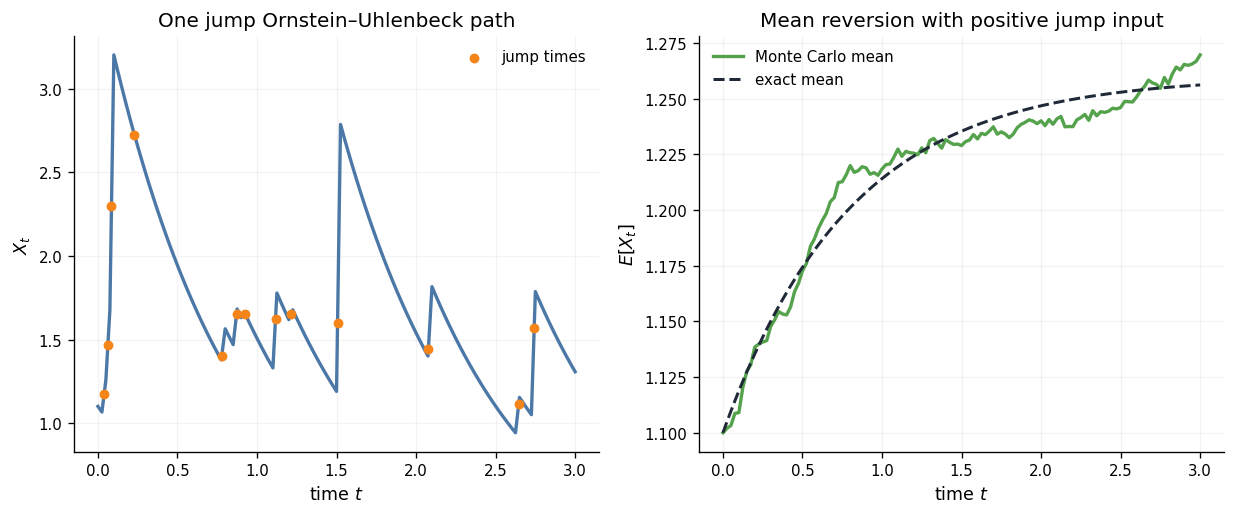

In [6]:
rng = np.random.default_rng(SEED + 5)
kappa = 1.25
rate = 3.5
mark_mean = 0.45
x0 = 1.1
horizon = 3.0
time_grid = np.linspace(0.0, horizon, 121)

def jump_ou_on_grid(event_times, event_marks):
    values = x0 * np.exp(-kappa * time_grid)
    for event_time, mark in zip(event_times, event_marks):
        mask = time_grid >= event_time
        values[mask] += mark * np.exp(-kappa * (time_grid[mask] - event_time))
    return values

sample_events = poisson_events(rate, horizon, rng)
sample_marks = rng.exponential(mark_mean, size=len(sample_events))
sample_path = jump_ou_on_grid(sample_events, sample_marks)

paths = 5_000
mean_path = np.zeros_like(time_grid)
for _ in range(paths):
    event_times = poisson_events(rate, horizon, rng)
    event_marks = rng.exponential(mark_mean, size=len(event_times))
    mean_path += jump_ou_on_grid(event_times, event_marks)
mean_path /= paths
theoretical_mean = (
    x0 * np.exp(-kappa * time_grid)
    + rate * mark_mean * (1.0 - np.exp(-kappa * time_grid)) / kappa
)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
axes[0].plot(time_grid, sample_path, color=BLUE, linewidth=2.0)
axes[0].scatter(sample_events, np.interp(sample_events, time_grid, sample_path), color=ORANGE, s=24, zorder=3, label="jump times")
axes[0].set(xlabel="time $t$", ylabel=r"$X_t$", title="One jump Ornstein–Uhlenbeck path")
axes[0].legend(frameon=False)

axes[1].plot(time_grid, mean_path, color=GREEN, linewidth=2.0, label="Monte Carlo mean")
axes[1].plot(time_grid, theoretical_mean, color=INK, linestyle="--", linewidth=1.8, label="exact mean")
axes[1].set(xlabel="time $t$", ylabel=r"$E[X_t]$", title="Mean reversion with positive jump input")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> An exact finite-activity jump Ornstein–Uhlenbeck path and a Monte Carlo check of its mean for exponential marks.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Between jumps the state decays exponentially, while each atom adds its mark at the jump time. The simulated mean follows the compensator-based formula, making explicit how the jump intensity and mean mark enter the drift of the expectation.</p>

## References

- Cont, R., and Tankov, P. *Financial Modelling with Jump Processes*. Chapman & Hall/CRC, 2004, Sections 2.6 and 8.1.4, especially Definition 2.18, Propositions 8.7–8.8, and equation (8.25) for Poisson random measures, compensation, predictable integrands, the compensated-integral isometry, and the sum-over-jumps representation.
- Klebaner, F. C. *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 9, Sections 9.1 and 9.4 for Poisson random measures, compensated integrals, and stochastic differential equations with jumps.